<a href="https://colab.research.google.com/github/Breezlyx/MineriaDeDatos-Entrega1/blob/main/Entrega_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1° Evaluación Minería de Datos: Análisis de Salarios

**Integrantes:** Francisco Sandoval y Nicko Cortes

**Justificación del Conjunto de Datos:**
Para este encargo se seleccionó el **"Job Salary Prediction Dataset"**, obtenido desde la plataforma Kaggle ([Enlace al Dataset](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset)). La elección se fundamenta en que cumple a cabalidad con los requisitos de admisibilidad: es un conjunto amplio, posee una mezcla equilibrada de variables categóricas y numéricas, y permite proyectar escenarios claros para aplicar futuros modelos de Machine Learning (como clasificación de modalidades de trabajo o regresión de salarios).

In [1]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Estudios/Mineria de Datos/job_salary_prediction_dataset.csv")

In [3]:
df.head() #visualizamos las primeras 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.tail()  #visualizamos las ultimas 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [5]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(250000, 10)

In [6]:
df.dtypes #observamos la columna y sus tipos de datos

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


# Mapeo y Tipos de Datos
A continuación se detalla el diccionario de datos, clasificando cada variable según su tipo informático (Python) y su naturaleza estadística intrínseca.

* **job_title:** Rol o posición de trabajo. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **experience_years:** Años de experiencia profesional. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **education_level:** Nivel más alto de educación completado. (Tipo Informático: `object` | Tipo Estadístico: Categórica Ordinal)
* **skills_count:** Número de habilidades técnicas. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **industry:** Sector de la industria al que pertenece. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **company_size:** Tamaño de la compañía. (Tipo Informático: `object` | Tipo Estadístico: Categórica Ordinal)
* **location:** Región o país del empleo. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **remote_work:** Permite o no trabajo remoto. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal / Binaria)
* **certifications:** Número de certificaciones profesionales. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **salary:** Salario anual en USD. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Continua)

In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


# Limpieza y Transformación de Datos
**Justificación:** El primer paso técnico es la limpieza de datos, un proceso fundamental para identificar y corregir registros incompletos o inexactos que puedan afectar la calidad del análisis. Se procede a verificar la existencia de valores nulos (faltantes) y registros duplicados en el conjunto de datos para determinar si es necesario aplicar técnicas de imputación o eliminación.

In [8]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


Como podemos observar, en nuestro dataset no hay presencia de valores nulos, por lo que no será necesario aplicar técnicas de limpieza en esta fase.

In [9]:
df.columns #mostramos los nombres de las columnas

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [10]:
df['education_level'].value_counts().count()

np.int64(5)

In [11]:
df['company_size'].value_counts().count()

np.int64(5)

In [12]:
df['industry'].value_counts().count()

np.int64(10)

In [13]:
df['location'].value_counts().count()

np.int64(10)

In [14]:
df['job_title'].value_counts().count()

np.int64(12)

# Análisis y Preprocesamiento: Encoding
**Justificación:** La mayoría de los algoritmos de Machine Learning no pueden procesar variables categóricas en formato de texto, por lo que es imperativo transformarlas a valores numéricos.

Para este proceso se aplica una técnica específica debido a la naturaleza de las variables
**One-Hot Encoding:** Se utiliza la librería *Scikit-Learn* para transformar `industry`, `remote_work`, `education_level` y `company_size`. En este método, se asigna cada categoría a un vector de ceros y unos. Esta técnica es ideal para variables nominales porque denota la presencia o ausencia de una característica sin imponer un orden lógico inexistente.

Se realiza one hot encoding para las columnas `education_level` y `company_size`

In [15]:
from sklearn.preprocessing import OneHotEncoder

# Creamos una copia de trabajo para mantener la cadena unida
df_encoded = df.copy()

# Instanciamos el codificador
ohc = OneHotEncoder()

# Transformamos 'industry' y 'remote_work' al mismo tiempo
ohe_data = ohc.fit_transform(df_encoded[['education_level', 'company_size']]).toarray()

# Creamos el DataFrame temporal con los nombres correctos
df_ohe = pd.DataFrame(ohe_data, columns=ohc.get_feature_names_out(['education_level', 'company_size']))

# Concatenamos los resultados a nuestro df_encoded
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

# Verificamos que existan columnas
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,education_level_Bachelor,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD,company_size_Enterprise,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Aplicamos One Hot Encoding para la columna `industry` y `remote_work`

In [16]:
# Instanciamos el codificador
ohc = OneHotEncoder()

# Transformamos 'industry' y 'remote_work' al mismo tiempo
ohe_data = ohc.fit_transform(df_encoded[['industry', 'remote_work']]).toarray()

# Creamos el DataFrame temporal con los nombres correctos
df_ohe = pd.DataFrame(ohe_data, columns=ohc.get_feature_names_out(['industry', 'remote_work']))

# Concatenamos los resultados a nuestro df_encoded
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

# Verificamos que ahora existan columnas como 'remote_work_Yes'
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


**Justificación (Binary Encoding):** Para las variables categóricas `job_title` y `location`, aplicar One-Hot Encoding generaría una cantidad excesiva de columnas debido a su alta cardinalidad, lo cual ralentiza significativamente el aprendizaje del modelo. Por ello, se opta por el **Binary Encoding**, técnica que convierte cada categoría a dígitos binarios, requiriendo muchas menos columnas de funciones y optimizando la estructura del dataset.

In [17]:
# Instalamos category_encoders
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.0 MB/s eta 0:00:00


In [18]:
import category_encoders as ce

# Instanciamos el codificador para alta cardinalidad
encoder = ce.BinaryEncoder(cols=['job_title', 'location'])

# Transformamos TODO el DataFrame.
df_encoded = encoder.fit_transform(df_encoded)

# Visualizamos la tabla final
df_encoded.head()

,job_title_0,job_title_1,job_title_2,job_title_3,experience_years,education_level,skills_count,industry,company_size,location_0,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0,0,0,1,10,Bachelor,2,Healthcare,Medium,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,0,5,Bachelor,17,Telecom,Small,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,0,1,1,18,PhD,4,Media,Medium,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,0,0,19,PhD,13,Retail,Medium,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,15,Bachelor,7,Manufacturing,Large,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [19]:
#Verificamos que las columnas del df original se mantengan integras
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [20]:
columns_to_drop = df_encoded.select_dtypes(include=['object']).columns
df_encoded = df_encoded.drop(columns=columns_to_drop)

print("Columnas eliminadas:", columns_to_drop.tolist())
print("Primeras 5 filas del DataFrame con columnas no codificadas eliminadas:")
df_encoded.head()

Columnas eliminadas: ['education_level', 'industry', 'company_size', 'remote_work']
Primeras 5 filas del DataFrame con columnas no codificadas eliminadas:


,job_title_0,job_title_1,job_title_2,job_title_3,experience_years,skills_count,location_0,location_1,location_2,location_3,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0,0,0,1,10,2,0,0,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,0,5,17,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,0,1,1,18,4,0,0,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,0,0,19,13,0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,15,7,0,1,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
#Varificamos que no queden datos sucios en el dataframe (Solo variables numericas para analizar)
df_encoded.columns

Index(['job_title_0', 'job_title_1', 'job_title_2', 'job_title_3',
       'experience_years', 'skills_count', 'location_0', 'location_1',
       'location_2', 'location_3', 'certifications', 'salary',
       'education_level_Bachelor', 'education_level_Diploma',
       'education_level_High School', 'education_level_Master',
       'education_level_PhD', 'company_size_Enterprise', 'company_size_Large',
       'company_size_Medium', 'company_size_Small', 'company_size_Startup',
       'industry_Consulting', 'industry_Education', 'industry_Finance',
       'industry_Government', 'industry_Healthcare', 'industry_Manufacturing',
       'industry_Media', 'industry_Retail', 'industry_Technology',
       'industry_Telecom', 'remote_work_Hybrid', 'remote_work_No',
       'remote_work_Yes'],
      dtype='object')

# Matriz de Correlación de Pearson
**Justificación:** Finalmente, se busca determinar de manera objetiva la relación lineal existente entre las variables numéricas y transformadas del dataset. Para ello, se calcula el coeficiente de correlación de Pearson, el cual evalúa asociaciones en una escala de -1 a +1, y se proyecta visualmente utilizando un mapa de calor (Heatmap) generado con la librería *Seaborn*.

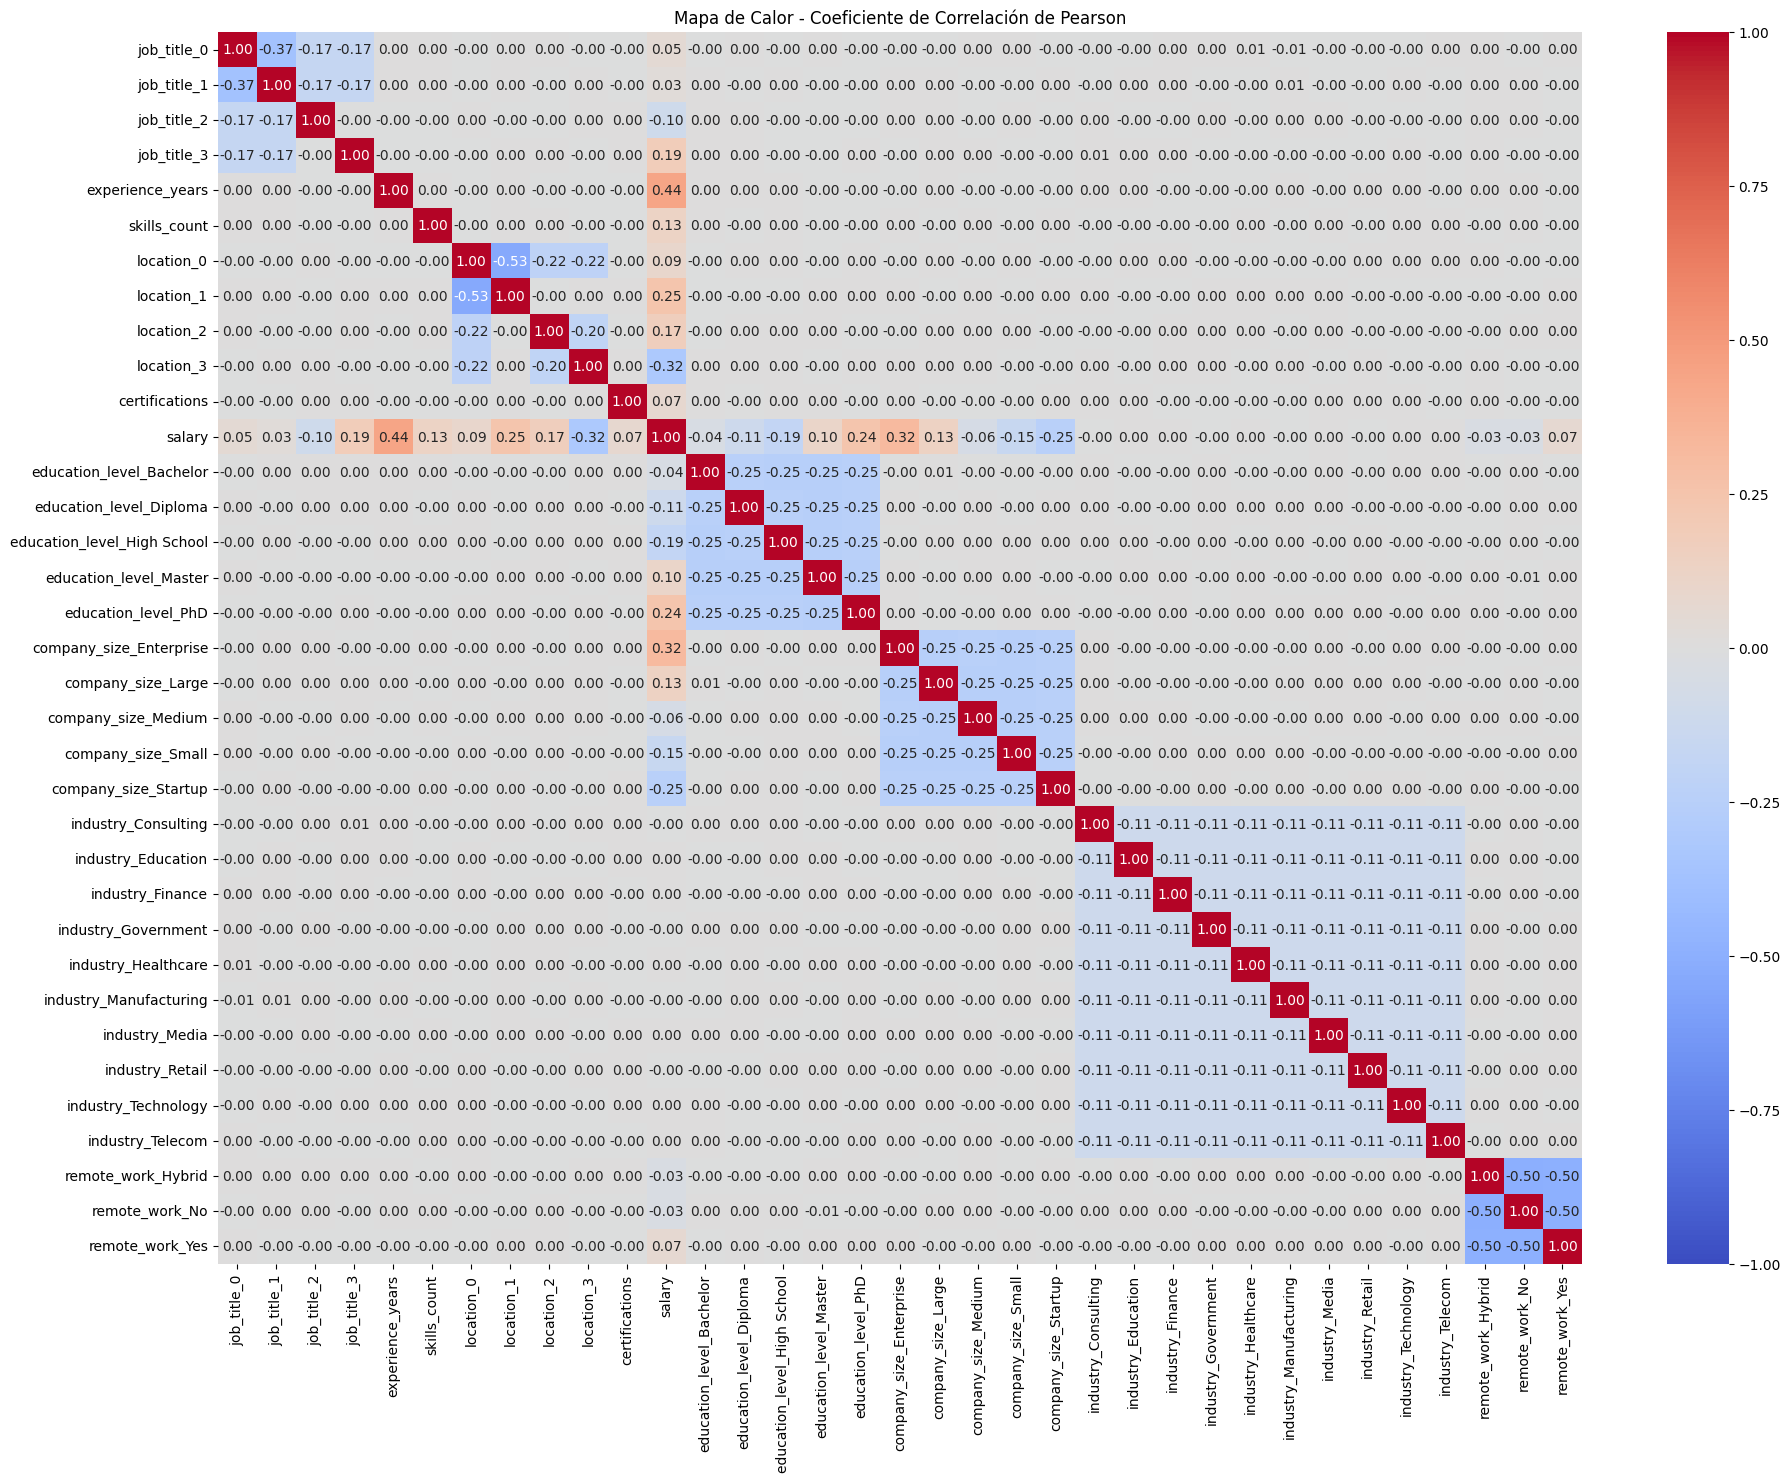

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la matriz de Pearson
matriz_correlacion = df_encoded.corr()

# Ajustamos el tamaño
plt.figure(figsize=(22, 16))

# Generamos el mapa de calor
sns.heatmap(matriz_correlacion, vmin=-1, vmax=+1, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de Calor - Coeficiente de Correlación de Pearson")
plt.show()

### Análisis de Correlación de Pearson

**Justificación Metodológica:**
Se ha generado una matriz de correlación utilizando el coeficiente de Pearson para cuantificar la fuerza y dirección de la relación lineal entre las variables numéricas y las transformadas mediante técnicas de encoding. El uso de un mapa de calor (Heatmap) permite identificar visualmente patrones de dependencia: los tonos que se acercan a +1 indican una correlación positiva, los que se acercan a -1 una correlación negativa, y los cercanos a 0 indican ausencia de relación lineal.

**Interpretación de los Resultados:**
Al analizar detalladamente los coeficientes de la matriz respecto a nuestra variable objetivo (`salary`), se extraen las siguientes conclusiones fundamentales para la comprensión del negocio:

1. **Principales Predictores del Salario:** La experiencia (`experience_years` = 0.44) y el tamaño de la empresa (`company_encoded` = 0.40) son los factores con mayor correlación positiva. Esto indica lógicamente que los profesionales con mayor trayectoria y aquellos que logran ingresar a compañías de mayor tamaño (como corporaciones o enterprises) perciben los sueldos más altos de la muestra.
2. **Impacto Moderado de la Educación:** El nivel educativo (`education_encoded` = 0.30) presenta una correlación positiva moderada. Esto demuestra que, si bien escalar en grados académicos (de Bachelor a Master o PhD) favorece un mejor sueldo, su peso no es tan decisivo como los años de experiencia práctica o el tipo de empresa que contrata.
3. **Variables con Baja o Nula Relación Lineal:** Sorprendentemente, características como la cantidad de habilidades técnicas (`skills_count` = 0.13) o el número de certificaciones (`certifications` = 0.07) tienen un impacto muy débil en el salario. Acumular certificados no garantiza una mejora salarial directa según este conjunto de datos.
4. **Indiferencia de la Modalidad de Trabajo:** Las modalidades de trabajo, evaluadas tras aplicar One-Hot Encoding (`hybrid_yes` = 0.07, `hybrid_no` = -0.03, `remote_work` = -0.03), muestran coeficientes prácticamente nulos. Esto permite concluir que, en este mercado, trabajar desde casa, híbrido o presencial no castiga ni beneficia el salario final.

## Fase 1: División del Conjunto de Datos (Data Splitting)

**Justificación Técnica:**
Dado que nuestra variable objetivo ("salary") es numérica continua, nos encontramos ante un problema de regresión. Nuestro dataset cuenta con un volumen masivo de **250.000 registros**.

Para evitar el sobreajuste y evaluar el modelo con rigor estadístico, aplicamos la técnica de *Data Splitting*:
1. **Conjunto de Entrenamiento (Train - 80%):** Destinamos 200.000 registros para que los algoritmos aprendan los patrones salariales.
2. **Conjunto de Prueba (Test - 20%):** Reservamos 50.000 registros como datos "invisibles". Esta es nuestra prueba de fuego para simular predicciones en el mundo real y calcular el error.

In [23]:
from sklearn.model_selection import train_test_split

# 1. Separamos las características (X) de la variable objetivo (y)
X = df_encoded.drop(columns=['salary'])
y = df_encoded['salary']

# 2. Dividimos los datos en Entrenamiento (0.8) y Prueba (0.2)
# El parámetro random_state=42 asegura que siempre obtengamos la misma división
# Esto es importante para que los resultados no cambien.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Total de registros originales: {df_encoded.shape[0]}")
print(f"Registros para Entrenar el modelo (X_train): {X_train.shape[0]}")
print(f"Registros para Probar el modelo (X_test): {X_test.shape[0]}")

Total de registros originales: 250000
Registros para Entrenar el modelo (X_train): 200000
Registros para Probar el modelo (X_test): 50000


## Fase 2: Selección y Entrenamiento de Modelos Predictivos

**Justificación Técnica y Estrategia:**
La Matriz de Pearson nos reveló que variables como `experience_years` (0.44) y `company_size` (0.40) tenían una clara correlación lineal positiva con el salario. Para poner a prueba este comportamiento, decidimos enfrentar dos enfoques opuestos:

1. **Regresión Lineal Múltiple (Modelo Paramétrico):** Nuestro modelo principal. Asume que el salario crece de forma constante y proporcional a medida que aumentan la experiencia o la educación.
2. **Árbol de Regresión (Modelo No Paramétrico):** Lo elegimos como modelo retador para capturar posibles relaciones no lineales. Queríamos comprobar si el salario daba "saltos" bruscos (por ejemplo, al pasar de un cargo Junior a Senior) en lugar de crecer en una línea recta. Limitamos su profundidad a 5 (`max_depth=5`) para prevenir el sobreajuste dado el gran volumen de datos.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# 1. MODELO PARAMÉTRICO: REGRESIÓN LINEAL MÚLTIPLE
# instanciamos el modelo
modelo_lineal = LinearRegression()

# entrenamos el modelo con los datos de entrenamiento
modelo_lineal.fit(X_train, y_train)

# generamos las predicciones usando los datos invisibles
predicciones_lineal = modelo_lineal.predict(X_test)

# 2. MODELO NO PARAMÉTRICO: ÁRBOL DE REGRESIÓN
# instanciamos el modelo.
# usamos max_depth=5 para limitar la profundidad del árbol.
# random_state=42 asegura que el árbol se construya igual cada vez que presenten(puede ser cualquier numero).
modelo_arbol = DecisionTreeRegressor(max_depth=5, random_state=42)

# entrenamos el modelo
modelo_arbol.fit(X_train, y_train)

# generamos las predicciones
predicciones_arbol = modelo_arbol.predict(X_test)

# La fase 2 fue completada y los modelos ya ha sido entrenados con exito.


## Fase 3: Evaluación y Análisis de Resultados

**Interpretación de Resultados:**
Al enfrentar las predicciones contra los 50.000 registros de prueba, obtuvimos resultados reveladores que validan nuestra hipótesis inicial de la Matriz de Pearson:



In [25]:
from sklearn.metrics import mean_squared_error, r2_score

# EVALUACIÓN DEL MODELO LINEAL

ecm_lineal = mean_squared_error(y_test, predicciones_lineal)
r2_lineal = r2_score(y_test, predicciones_lineal)

# EVALUACIÓN DEL ÁRBOL DE REGRESIÓN
ecm_arbol = mean_squared_error(y_test, predicciones_arbol)
r2_arbol = r2_score(y_test, predicciones_arbol)

# MOSTRAR RESULTADOS

print("RESULTADOS DE LA EVALUACIÓN PREDICTIVA ")

print("\n1 MODELO DE REGRESIÓN LINEAL MÚLTIPLE:")
print(f"    Error Cuadrático Medio : {ecm_lineal:,.2f}")
print(f"    Coeficiente de Ajuste (R^2):  {r2_lineal:.4f}")

print("\n2 ÁRBOL DE REGRESIÓN :")
print(f"    Error Cuadrático Medio : {ecm_arbol:,.2f}")
print(f"   Coeficiente de Ajuste (R^2):  {r2_arbol:.4f}")


RESULTADOS DE LA EVALUACIÓN PREDICTIVA 

1 MODELO DE REGRESIÓN LINEAL MÚLTIPLE:
    Error Cuadrático Medio : 337,731,740.45
    Coeficiente de Ajuste (R^2):  0.7570

2 ÁRBOL DE REGRESIÓN :
    Error Cuadrático Medio : 657,878,812.42
   Coeficiente de Ajuste (R^2):  0.5267


1. **Ganador - Regresión Lineal:**
   * **$R^2$ (0.7570):** El modelo lineal es capaz de explicar el **75.7%** de la varianza de los sueldos. Este es un porcentaje excepcionalmente alto para predicciones salariales, confirmando que la relación entre experiencia, tamaño de empresa y sueldo en esta industria es casi estrictamente lineal.
   * **ECM (337.731.740):** Aunque el número parece inmenso, al calcular su raíz cuadrada (RECM), descubrimos que el modelo tiene un margen de error promedio de **$18.377 USD** anuales. Considerando la dispersión global de salarios, es un margen muy competitivo.

2. **Árbol de Regresión:**
   * **$R^2$ (0.5267):** El árbol solo logró explicar el 52.6% de los datos. Su incapacidad para trazar líneas suaves y su tendencia a crear "escalones de predicción" lo hizo mucho más impreciso.
   * **ECM (657.878.812):** Su error fue de 7 dolares adicionales por lo cual le da menos veracidad al modelo de predicción que el del modelo paramétrico. El RECM da un valor de: **$25.649 USD**.

**Conclusión:** En la Minería de Datos, un modelo más complejo no siempre supera a uno más simple (Lineal) si la naturaleza de los datos tiende a proporciones lineales.

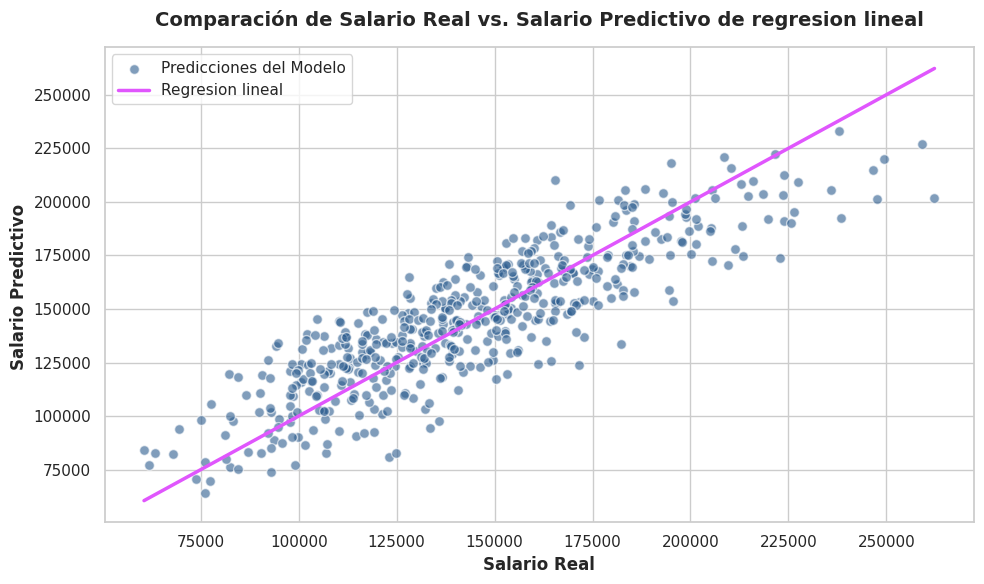

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression

# CONFIGURACION DEL GRAFICO
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Tomamos una muestra aleatoria de 500 registros para evitar el overplotting
np.random.seed(42)
indices_muestra = np.random.choice(len(y_test), size=500, replace=False)

# Filtramos la muestra tanto para los datos reales como para los predictivos
y_test_muestra = y_test.iloc[indices_muestra]
y_pred_muestra = predicciones_lineal[indices_muestra]

# CREACION VISUAL
# GRAFICO DE DISPERSION
plt.scatter(y_test_muestra, y_pred_muestra, alpha=0.6, color='#2b5c8f', edgecolors='w', s=50, label='Predicciones del Modelo')

# LINEA DE REGRESION
limite_min = min(y_test_muestra.min(), y_pred_muestra.min())
limite_max = max(y_test_muestra.max(), y_pred_muestra.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color='#e056fd', linestyle='-', linewidth=2.5, label='Regresion lineal')

# TITULOS Y ETIQUETA
plt.title('Comparación de Salario Real vs. Salario Predictivo de regresion lineal', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Salario Real', fontsize=12, fontweight='bold')
plt.ylabel('Salario Predictivo ', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)

formatter = ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')

# Desplegar el gráfico
plt.tight_layout()
plt.show()

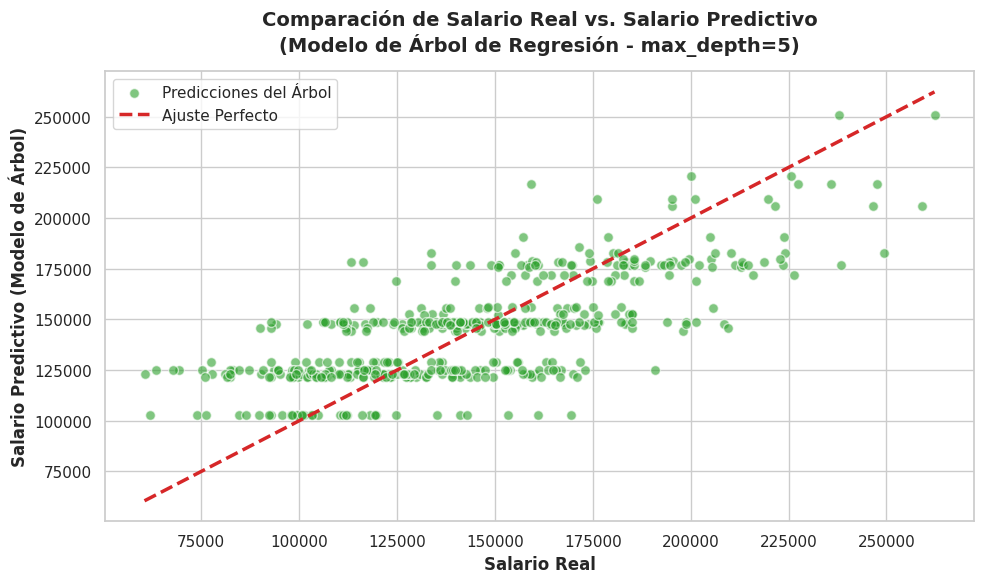

In [27]:

# GRAFICO
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#MUESTRA PARA EVITAR OVERPLOTTING
np.random.seed(42)
indices_muestra = np.random.choice(len(y_test), size=500, replace=False)

# Filtramos la muestra usando las variables de tu código
y_test_muestra = y_test.iloc[indices_muestra]
y_pred_muestra_arbol = predicciones_arbol[indices_muestra]

#GRÁFICO DE DISPERSIÓN
plt.scatter(y_test_muestra, y_pred_muestra_arbol, alpha=0.6, color='#2ca02c', edgecolors='w', s=50, label='Predicciones del Árbol')

# Linea de ajuste
limite_min = min(y_test_muestra.min(), y_pred_muestra_arbol.min())
limite_max = max(y_test_muestra.max(), y_pred_muestra_arbol.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color='#d62728', linestyle='--', linewidth=2.5, label='Ajuste Perfecto ')

# TITULOS Y ETIQUETAS
plt.title('Comparación de Salario Real vs. Salario Predictivo\n(Modelo de Árbol de Regresión - max_depth=5)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Salario Real', fontsize=12, fontweight='bold')
plt.ylabel('Salario Predictivo (Modelo de Árbol)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)

# DESPLEGAR GRÁFICO
plt.tight_layout()
plt.show()

## Experiencia Práctica y Resolución de Problemas

Durante el desarrollo de este encargo grupal, enfrentamos dos grandes hitos técnicos y analíticos:

1. **Problema de Alta Dimensionalidad:** Al intentar procesar `job_title` y `location`, nos dimos cuenta de que aplicar *One-Hot Encoding* iba a generar cientos de columnas, amenazando con colapsar la memoria y el rendimiento de los modelos. Lo resolvimos investigando e implementando *Binary Encoding*, comprimiendo la información en bits y manteniendo el dataset ágil.
2. **La trampa de la complejidad:** Inicialmente, teniamos la creencia que el arbol de Decisión sería superior por su capacidad de encontrar patrones ocultos y jerarquías (ej. Cargo > Industria > Experiencia). Sin embargo, la práctica nos enseñó a confiar en la estadística descriptiva: nuestra matriz de correlación ya nos había advertido de un fuerte comportamiento lineal. Aprendimos que forzar un modelo de particiones no paramétricas sobre datos lineales solo duplica el margen de error.